# Pandas - Simple functions

The Pandas library is a powerful and essential tool in data analysis and manipulation using Python. Its significance lies in its ability to handle structured data efficiently, providing data structures like DataFrames that simplify tasks such as cleaning, transforming, and analyzing datasets. Mastering the Pandas library is crucial for anyone working with data in Python, as it offers a wide range of functions and methods for data manipulation, exploration, and statistical analysis. To become proficient in pandas, one should start by familiarizing themselves with the core concepts of **Series** and **DataFrame**, understanding **data indexing**, and exploring the many functions available for **data filtering, grouping, and merging**.

Additionally, hands-on practice with real-world datasets and challenging tasks is critical to mastering pandas, as it allows users to apply their knowledge in practical scenarios, reinforcing their skills and deepening their understanding of this indispensable library.








## Step 0: Import Modules

In [2]:
# import numpy as np
import pandas as pd
Ver=31.25

##Step 1: Download the Data File



*   Download the csv file from the link below:

    https://drive.google.com/uc?id=1ZyQBMoM81Nh7Lgp_J0MMdHe68opjAtsb

*   Click on the folder button on the left side and upload the csv file to your Colab.


<font color=red>Basically, you are downloading the file from Mehdi's Google drive.</font>

##Step 2: File Verification


Verify whether you possess the Excel file named <font color='red'>"GlobalLandTemperaturesByCity.csv"</font> in your Colab system by clicking on the folder button located on the left side of your screen.






## Step 3: Load the Data file
Run the following command to load the csv file to a dataframe. </br><font color=red> [Do NOT change the comand below]

In [3]:
df_raw = pd.read_csv('GlobalLandTemperaturesByCity.csv')

##Step 4:  Explore the Data
Explore the dataset till you have a good idea about the dataset. Eg, use methods like .head() , .info() etc..

In [4]:
df_raw.info()
df_raw.head()

<class 'pandas.DataFrame'>
RangeIndex: 8599212 entries, 0 to 8599211
Data columns (total 7 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   dt                             str    
 1   AverageTemperature             float64
 2   AverageTemperatureUncertainty  float64
 3   City                           str    
 4   Country                        str    
 5   Latitude                       str    
 6   Longitude                      str    
dtypes: float64(2), str(5)
memory usage: 459.2 MB


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


##Step4: Parse the time stamp
Complete the second line of the following code to parse the time stamp in the dataset and define the new dataframe called <font color='red'> df </font>. <br>Feel free to write as many line of code as you need  

In [5]:
### BEGIN SOLUTION
df=df_raw.copy()

df['dt'] = pd.to_datetime(df['dt'])


### END SOLUTION

In [6]:
# Run this cell to make sure the new dataframe is created and the timestamp is parsed. Dtype in front of dt should be datetime
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8599212 entries, 0 to 8599211
Data columns (total 7 columns):
 #   Column                         Dtype         
---  ------                         -----         
 0   dt                             datetime64[us]
 1   AverageTemperature             float64       
 2   AverageTemperatureUncertainty  float64       
 3   City                           str           
 4   Country                        str           
 5   Latitude                       str           
 6   Longitude                      str           
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 459.2 MB


## Step 5: Gap in Data


When you run the following command, you should see that the `AverageTemperature` column contains some `NaN` values.




In [7]:
df['AverageTemperature'].head(10)

0     6.068
1       NaN
2       NaN
3       NaN
4       NaN
5     5.788
6    10.644
7    14.051
8    16.082
9       NaN
Name: AverageTemperature, dtype: float64

Fill in the parentheses to get rid of any record with unacceptable values in `AverageTemperature` Column and define a dataframe called <font color=red> `df_drop` </font> which has the cleansed data

In [8]:
### BEGIN SOLUTION

df_drop = df.dropna(subset='AverageTemperature')


### END SOLUTION

If you write the command correctly, running the following command should not show any `NaN`.

In [9]:
df_drop['AverageTemperature'].head(10)

0      6.068
5      5.788
6     10.644
7     14.051
8     16.082
10    12.781
11     7.950
12     4.639
13     0.122
14    -1.333
Name: AverageTemperature, dtype: float64

## Step 6: Index change
In the first line, we copy the `df_drop` to a new dataframe called `df_time`. Complete the second line to set the index of the `df_time` to be the parsed timestamp, column `dt`.

In [10]:
### BEGIN SOLUTION
df_time=df_drop.copy()

df_time = df_time.set_index('dt')

### END SOLUTION

Make sure to run the following command to double check that the `dt` (time stamp) is the index now!

In [11]:
df_time.head()

,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
dt,,,,,,
1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1744-04-01,5.788,3.624,Århus,Denmark,57.05N,10.33E
1744-05-01,10.644,1.283,Århus,Denmark,57.05N,10.33E
1744-06-01,14.051,1.347,Århus,Denmark,57.05N,10.33E
1744-07-01,16.082,1.396,Århus,Denmark,57.05N,10.33E


## Step 7: Data Selection
How many records are in the DataFrame `df_time` for the Country of `Jordan`? Store your answer in a varibale called <font color='red'>`count_Jordan`</font><br>
Hint: Spesify the country to be `Jordan` and then use .count().

In [12]:
### BEGIN SOLUTION

count_Jordan=(df_time['Country'] == 'Jordan').count()

### END SOLUTION

<font color=red> Running the following command should display a single number, not a set of numbers.


In [13]:
print(count_Jordan)

8235082


## Step 8: Re-Sampling
In this step, we would like to create **yearly** average of `AverageTemperature` for the Country of <font color=red>`Taiwan`</font> and City of <font color=red>`Taichung`</font>.

Hint: Just complete the following Code!
1.   In the first line, specify the Country and City for selecting certain rows and define the new dataframe called `df_Taiwan`.
2.   In the second line, complete the Re-sampleing parameters to have yearly data.


In [14]:
### BEGIN SOLUTION

df_Taiwan=df_time['AverageTemperature'][(df_time['Country'] == 'Taiwan') & (df_time['City'] == 'Taichung')]
df_Taiwan_Mean=df_Taiwan.resample('1YE').mean()

### END SOLUTION

<Axes: xlabel='dt'>

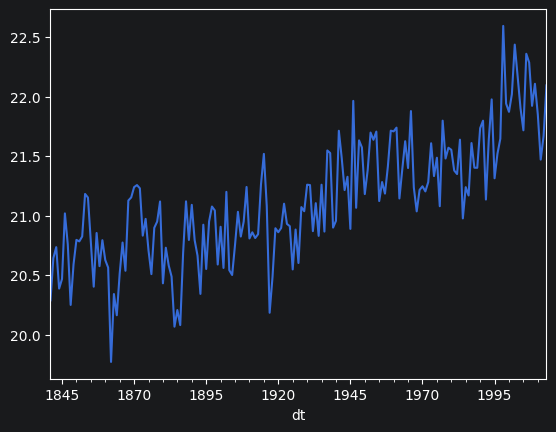

In [15]:
# If you done everything correct, the following code should create a plot for you:
df_Taiwan_Mean.plot()